In [1]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd

In [2]:
iris = load_iris()

In [3]:
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
y = iris.target

In [4]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
X.shape

(150, 4)

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

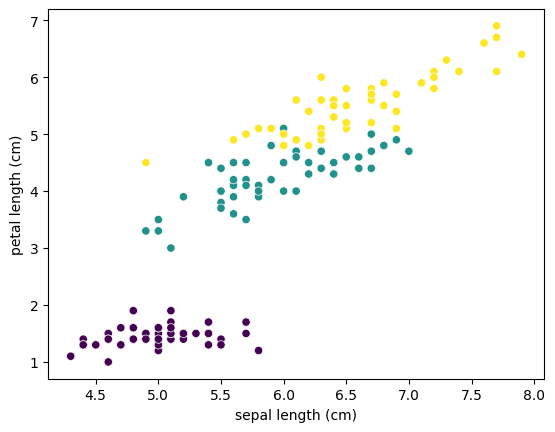

In [7]:
# Visualize 2 Features :

sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,2],c=y)

In [8]:
from sklearn.preprocessing import StandardScaler

cols = X.columns
std = StandardScaler()
X_scaled = pd.DataFrame(std.fit_transform(X),columns=cols)

In [9]:
X_scaled.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
49,-1.021849,0.558611,-1.340227,-1.315444
59,-0.779513,-0.822570,0.080709,0.264142
34,-1.143017,0.098217,-1.283389,-1.315444
12,-1.264185,-0.131979,-1.340227,-1.447076
88,-0.294842,-0.131979,0.194384,0.132510


In [10]:
# Elbow Method :

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

In [11]:
from kneed import KneeLocator

knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

print(knee.elbow)

3


<Axes: >

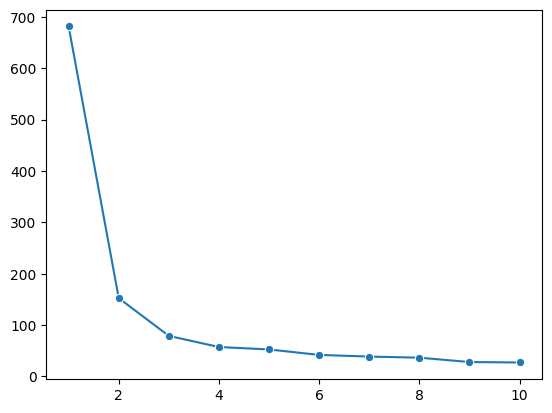

In [12]:
sns.lineplot(x=range(1,11),y=wcss,marker="o")

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

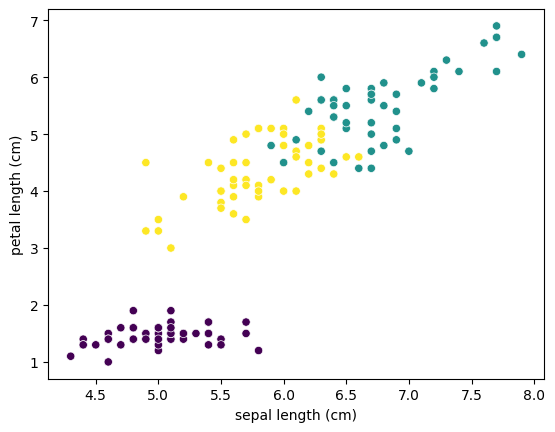

In [13]:
# K - Means :

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,2],c=labels)

<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

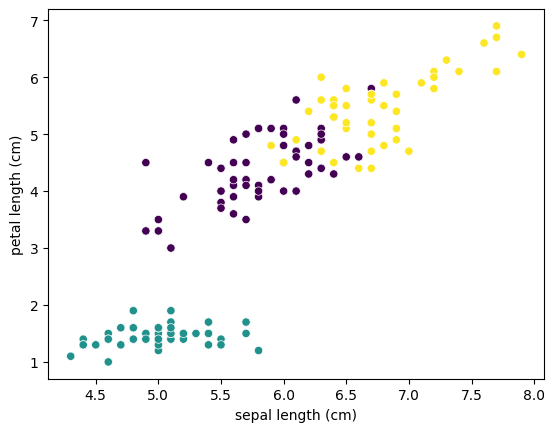

In [14]:
# Dimensionality Reduction :

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3)

labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=X.iloc[:,0],y=X.iloc[:,2],c=labels)

<Axes: >

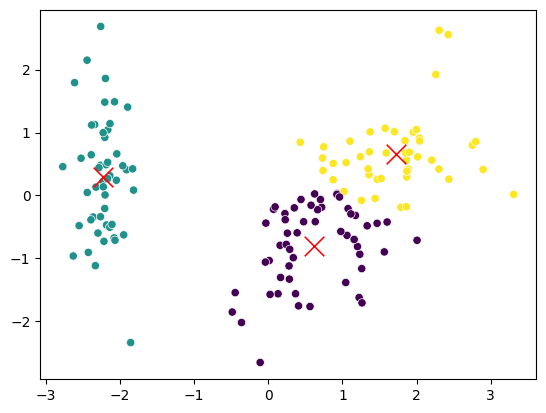

In [15]:
# Centroids :

sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],c="red",marker="x",s=200)

In [36]:
# Silhoutte Score :

from sklearn.metrics import silhouette_score

ss = []

for k in range(2,20):
    kmeans = KMeans(n_clusters=k)
    pred = kmeans.fit_predict(X_scaled)
    ss.append(silhouette_score(X,pred))

print(ss)

[0.6867350732769777, 0.49291104117175477, 0.37993506937374366, 0.3065949861593054, 0.2663438355355282, 0.2739783872974051, 0.2504386847463529, 0.21164432681103607, 0.26283214915277786, 0.23737514572270915, 0.2544656123813133, 0.2131368377424004, 0.22907701689860355, 0.17135962536813706, 0.20640823242744977, 0.19987202051664302, 0.18275181521713543, 0.21523318445197318]


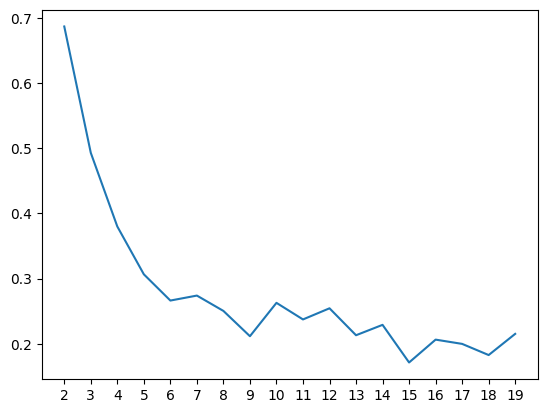

In [37]:
import matplotlib.pyplot as plt
sns.lineplot(x=range(2,20),y=ss)
plt.xticks(range(2,20))
plt.show()